In [21]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
import os
os.environ["OMP_NUM_THREADS"] = "1"
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import seaborn as sns

# Set random seed for reproducibility
np.random.seed(42)
print("="*80)

In [22]:
print("Loading data")
print("="*80)
#Loading in data
file_path = r"C:\Users\kenne\Downloads\PWT11_clean_2019 (version 1).xlsb.xlsx"
EconometricData = pd.read_excel(file_path, sheet_name="Sheet3")
print (EconometricData.head())
print("="*80)

Loading data
  countrycode               country  year          rgdpo        pop  \
0         ABW                 Aruba  2021    4026.352539   0.107558   
1         AGO                Angola  2021  215422.875000  34.532429   
2         AIA              Anguilla  2021     268.632935   0.014475   
3         ALB               Albania  2021   42296.042969   2.849635   
4         ARE  United Arab Emirates  2021  711028.125000   9.789048   

         emp      avh        hc        ck      ctfp  rtfpna  
0   0.048457      NaN       NaN  0.000222       NaN     NaN  
1  16.094906  2067.72  1.507136  0.008424  0.485366     1.0  
2        NaN      NaN       NaN       NaN       NaN     NaN  
3   1.127748  2125.82  3.004053  0.001782  0.476835     1.0  
4   5.999405  2657.34  3.254923       NaN       NaN     NaN  


In [23]:
print ("data exploration")
print("="*80)

print("\nColumn information:")
print(EconometricData.info())
print("="*80)

print("\ndescribe information:")
print(EconometricData.info())
print("="*80)

print("\nColumn information:")
print(EconometricData.describe())
print("="*80)

print("\nMissing values:")
print(EconometricData.isnull().sum())
print("="*80)

data exploration

Column information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 185 entries, 0 to 184
Data columns (total 11 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   countrycode  185 non-null    object 
 1   country      185 non-null    object 
 2   year         185 non-null    int64  
 3   rgdpo        185 non-null    float64
 4   pop          185 non-null    float64
 5   emp          179 non-null    float64
 6   avh          130 non-null    float64
 7   hc           145 non-null    float64
 8   ck           139 non-null    float64
 9   ctfp         120 non-null    float64
 10  rtfpna       120 non-null    float64
dtypes: float64(8), int64(1), object(2)
memory usage: 16.0+ KB
None

describe information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 185 entries, 0 to 184
Data columns (total 11 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   countrycode  185 non-null 

In [24]:
print("Identifying Removed Countries")
print("="*80)

data_clean = EconometricData.dropna()

countries_before = EconometricData['country'].tolist()
country_codes_before = EconometricData['countrycode'].tolist()

print(f"Total countries before cleaning: {len(countries_before)}")


countries_after = data_clean['country'].tolist()
country_codes_after = data_clean['countrycode'].tolist()

print(f"Total countries after cleaning: {len(countries_after)}")
print(f"Countries removed: {len(countries_before) - len(countries_after)}")


removed_countries = set(countries_before) - set(countries_after)
removed_country_codes = set(country_codes_before) - set(country_codes_after)

print(f" REMOVED COUNTRIES ({len(removed_countries)}):")
print("="*80)


removed_list = []
for i, country in enumerate(EconometricData['country']):
    if country in removed_countries:
        code = EconometricData.iloc[i]['countrycode']
        removed_list.append((code, country))

removed_list = sorted(set(removed_list)) 
for i, (code, country) in enumerate(removed_list, 1):
    print(f"  {i:2d}. {code} - {country}")
    
print("="*80)

Identifying Removed Countries
Total countries before cleaning: 185
Total countries after cleaning: 103
Countries removed: 82
 REMOVED COUNTRIES (82):
   1. ABW - Aruba
   2. AIA - Anguilla
   3. ARE - United Arab Emirates
   4. ATG - Antigua and Barbuda
   5. AZE - Azerbaijan
   6. BDI - Burundi
   7. BEN - Benin
   8. BGD - Bangladesh
   9. BHS - Bahamas
  10. BIH - Bosnia and Herzegovina
  11. BLR - Belarus
  12. BLZ - Belize
  13. BMU - Bermuda
  14. BRB - Barbados
  15. BRN - Brunei Darussalam
  16. BTN - Bhutan
  17. CAF - Central African Republic
  18. COD - D.R. of the Congo
  19. COG - Congo
  20. COM - Comoros
  21. CPV - Cabo Verde
  22. CUW - Curaçao
  23. CYM - Cayman Islands
  24. DJI - Djibouti
  25. DMA - Dominica
  26. DZA - Algeria
  27. ETH - Ethiopia
  28. FJI - Fiji
  29. GEO - Georgia
  30. GHA - Ghana
  31. GIN - Guinea
  32. GMB - Gambia
  33. GNB - Guinea-Bissau
  34. GNQ - Equatorial Guinea
  35. GRD - Grenada
  36. GUY - Guyana
  37. HND - Honduras
  38. HTI -

In [25]:
print("selecting features")
print("="*80)

feature_columns = ['rgdpo','pop', 'emp', 'avh' , 'hc', 'ck' ,'ctfp',]

print("List of Selected features:")
for i, col in enumerate(feature_columns, 1):
    print(f"  {i}. {col}")

X = data_clean[feature_columns].values
print(f"Feature matrix created with shape: {X.shape}")
print("="*80)

selecting features
List of Selected features:
  1. rgdpo
  2. pop
  3. emp
  4. avh
  5. hc
  6. ck
  7. ctfp
Feature matrix created with shape: (103, 7)


In [26]:
print("Scaling data/features")
print("="*80)

# StandardScaler standardizes features to mean=0, std=1
# Better for K-means because it handles outliers better
# and assumes normal distribution
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("Using StandardScaler (mean=0, std=1):")
print('')
print(f"  Mean: {scaler.mean_}")
print(f"  Std:  {scaler.scale_}")

# Verify standardization
print(f"\nVerification:")
print(f"  Mean of scaled features: {X_scaled.mean(axis=0).round(10)}")
print(f"  Std of scaled features:  {X_scaled.std(axis=0).round(2)}")

Scaling data/features
Using StandardScaler (mean=0, std=1):

  Mean: [1.39195395e+06 6.28536442e+01 2.78529417e+01 1.89513282e+03
 2.94855341e+00 6.59677451e-02 6.58797592e-01]
  Std:  [3.84030926e+06 1.98951893e+02 9.42400134e+01 2.98723770e+02
 6.22591715e-01 1.77919676e-01 2.24293498e-01]

Verification:
  Mean of scaled features: [-0.  0.  0.  0.  0.  0.  0.]
  Std of scaled features:  [1. 1. 1. 1. 1. 1. 1.]


In [27]:
print("using Elbo method to find optimal k")
# we use the elbo method to find the otimal amount of clusters
# we will be testing k from 1-10
print("="*80)

inertias = []
K_range = range(1, 11)
for k in K_range:
    kmeans_temp = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans_temp.fit(X_scaled)
    inertias.append(kmeans_temp.inertia_)
    print(f"  K={k:2d}: Inertia = {kmeans_temp.inertia_:,.2f}")
print("="*80)

using Elbo method to find optimal k


C:\Users\kenne\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1446: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


  K= 1: Inertia = 721.00


C:\Users\kenne\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1446: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


  K= 2: Inertia = 406.10


...

  K= 8: Inertia = 116.20


C:\Users\kenne\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1446: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


  K= 9: Inertia = 103.16


C:\Users\kenne\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1446: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


  K=10: Inertia = 93.85


ploting elbo method


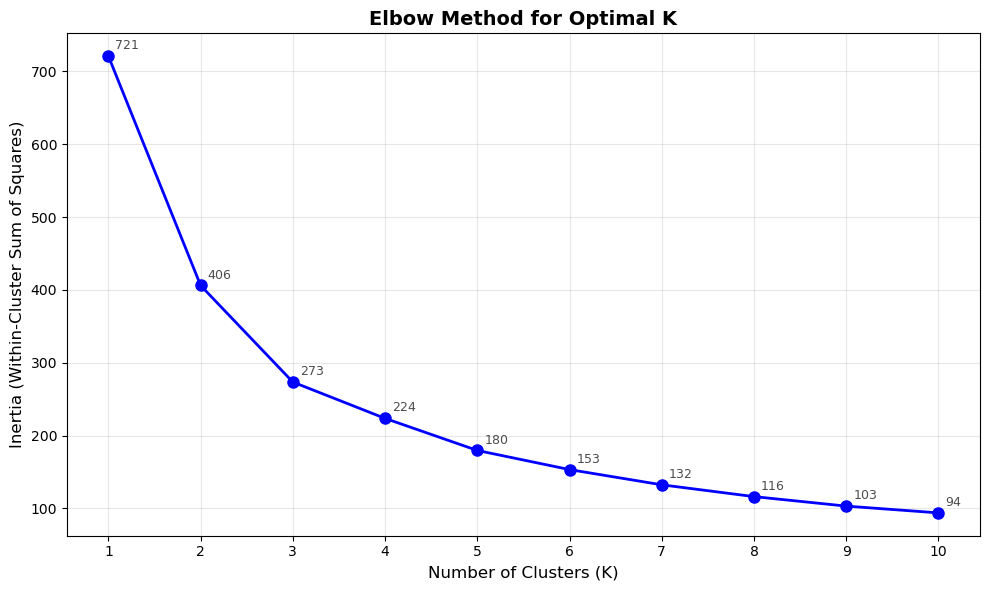

In [28]:
print ("ploting elbo method")
print("="*80)
plt.figure(figsize=(10, 6))
plt.plot(K_range, inertias, 'bo-', linewidth=2, markersize=8)
plt.xlabel('Number of Clusters (K)', fontsize=12)
plt.ylabel('Inertia (Within-Cluster Sum of Squares)', fontsize=12)
plt.title('Elbow Method for Optimal K', fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.3)
plt.xticks(K_range)

for k, inertia in zip(K_range, inertias):
    plt.annotate(f'{inertia:.0f}', 
                xy=(k, inertia), 
                xytext=(5, 5), 
                textcoords='offset points',
                fontsize=9,
                alpha=0.7)
    plt.tight_layout()
#we can see from the plot the the optimal number of clusters is 3
#Therefore we assign the variable 'optimal_k' as 3 for later use in the algortihm
optimal_k = 3

In [29]:
print("fitting model")
print("="*80)

kmeans = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
kmeans.fit(X_scaled)

cluster_labels = kmeans.labels_
print("="*80)

fitting model


C:\Users\kenne\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1446: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


In [40]:
print("Cluster analysis")
print("="*80)

data_clean_copy = data_clean.copy()
data_clean_copy['Cluster'] = cluster_labels 

print("\nCluster sizes:")
for i in range(optimal_k):
    count = np.sum(cluster_labels == i)
    percentage = (count / len(cluster_labels)) * 100
    print(f"  Cluster {i+1}: {count:3d} countries ({percentage:.1f}%)")


cluster_means = data_clean_copy.groupby('Cluster')[feature_columns].mean()

for i in range(optimal_k):
    print(f"\n{'='*60}")
    print(f"CLUSTER {i+1}")
    print('='*60)
    
    
    cluster_mask = cluster_labels == i
    countries_in_cluster = data_clean['country'][cluster_mask].tolist()
    
    print(f"\nCountries ({len(countries_in_cluster)} total):")
    print("-" * 40)
    
    
    cols = 4 
    for j in range(0, len(countries_in_cluster), cols):
        row_countries = countries_in_cluster[j:j+cols]
        
        formatted_row = [f"{country:20}" for country in row_countries]
        print("  " + "".join(formatted_row))
    
    print(f"\nCluster characteristics (mean values):")
    print("-" * 40)
    print(cluster_means.loc[i].round(3))
    
 #This show cases key statistics
    cluster_data = data_clean[cluster_mask]
    print(f"\nKey statistics:")
    print(f"  GDP range:      ${cluster_data['rgdpo'].min():,.0f} to ${cluster_data['rgdpo'].max():,.0f}")
    print(f"  Population range: {cluster_data['pop'].min():,.1f}M to {cluster_data['pop'].max():,.1f}M")
    print(f"  TFP range:      {cluster_data['ctfp'].min():.3f} to {cluster_data['ctfp'].max():.3f}")
    print(f"  Human capital range: {cluster_data['hc'].min():.2f} to {cluster_data['hc'].max():.2f}")

Cluster analysis

Cluster sizes:
  Cluster 1:  52 countries (50.5%)
  Cluster 2:   3 countries (2.9%)
  Cluster 3:  48 countries (46.6%)

CLUSTER 1

Countries (52 total):
----------------------------------------
  Argentina           Australia           Austria             Belgium             
  Bulgaria            Canada              Switzerland         Chile               
  Cyprus              Czechia             Germany             Denmark             
  Ecuador             Egypt               Spain               Estonia             
  Finland             France              Gabon               United Kingdom      
  Greece              China, Hong Kong SARCroatia             Hungary             
  Ireland             Iraq                Iceland             Israel              
  Italy               Japan               Kazakhstan          Republic of Korea   
  Lithuania           Luxembourg          Latvia              Mexico              
  Malta               Mauritius          

print("Interactive 3D Visualization")
try:
    import plotly.express as px
    import plotly.graph_objects as go
    
    # 3D scatter plot
    fig = px.scatter_3d(data_clean_copy, 
                        x='rgdpo', 
                        y='pop', 
                        z='ctfp',
                        color='Cluster_Name',
                        hover_name='country',
                        size='hc',
                        opacity=0.7,
                        title='3D Cluster Visualization',
                        labels={'rgdpo': 'Real GDP', 
                                'pop': 'Population', 
                                'ctfp': 'TFP',
                                'hc': 'Human Capital'})
    
    fig.update_layout(scene=dict(
        xaxis_title="GDP (log scale)",
        yaxis_title="Population (log scale)",
        zaxis_title="TFP"),
        width=1000, height=800)
    
    fig.show()
    
except ImportError:
    print("Install plotly for interactive visualizations: pip install plotly")

In [1]:
import plotly.express as px
import plotly.graph_objects as go
import os
# Create your interactive plot
fig = px.scatter_3d(data_clean_copy, 
                    x='rgdpo', 
                    y='pop', 
                    z='ctfp',
                    color='Cluster_Name',
                    hover_name='country',
                    size='hc',
                    opacity=0.7,
                    title='3D Cluster Visualization')

# Save as HTML file
fig.write_html("cluster_visualization.html")

print("✓ Interactive graph saved as 'cluster_visualization.html'")
print("  You can open this file in any web browser (Chrome, Firefox, etc.)")
print("  The interactivity (hover, zoom, rotate) will be preserved!")

NameError: name 'data_clean_copy' is not defined

In [48]:
import os

# Show current working directory
current_dir = os.getcwd()
print(f"Current working directory: {current_dir}")

# Create and save the plot
fig.write_html("cluster_interactive.html")

# Show the full path
file_path = os.path.join(current_dir, "cluster_interactive.html")
print(f"File will be saved at: {file_path}")

Current working directory: C:\Users\kenne
File will be saved at: C:\Users\kenne\cluster_interactive.html
